In [3]:
import numpy as np
import pandas as pd
import cv2
import PIL
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [4]:
os.listdir()

['.virtual_documents']

In [5]:
dataset_url = '/kaggle/input/datasets/subirbiswas19/skin-disease-dataset/skin-disease-datasaet/test_set'

In [6]:
os.listdir(dataset_url)

['FU-nail-fungus',
 'FU-ringworm',
 'VI-shingles',
 'BA-impetigo',
 'FU-athlete-foot',
 'VI-chickenpox',
 'PA-cutaneous-larva-migrans',
 'BA- cellulitis']

In [7]:
import pathlib
data_dir=pathlib.Path(dataset_url)
data_dir

PosixPath('/kaggle/input/datasets/subirbiswas19/skin-disease-dataset/skin-disease-datasaet/train_set')

In [8]:
cellulitis=list(data_dir.glob('BA- cellulitis/*'))
len(cellulitis)

136

In [9]:
FU_athlete_foot=list(data_dir.glob('FU-athlete-foot/*'))
len(FU_athlete_foot)

124

In [10]:
VI_chickenpoxt=list(data_dir.glob('VI-chickenpox/*'))
len(VI_chickenpoxt)

136

In [11]:
VI_shingles=list(data_dir.glob('VI-shingles/*'))
len(VI_shingles)

130

In [12]:
FU_nail_fungus=list(data_dir.glob('FU-nail-fungus/*'))
len(FU_nail_fungus)

129

In [13]:
BA_impetigo=list(data_dir.glob('BA-impetigo/*'))
len(BA_impetigo)

80

In [14]:
FU_ringworm=list(data_dir.glob('FU-ringworm/*'))
len(FU_ringworm)

90

In [15]:
PA_cutaneous_larva_migrans=list(data_dir.glob('PA-cutaneous-larva-migrans/*'))
len(PA_cutaneous_larva_migrans)

100

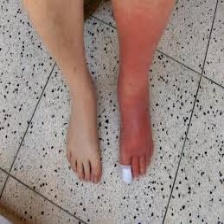

In [16]:
PIL.Image.open(str(cellulitis[6]))

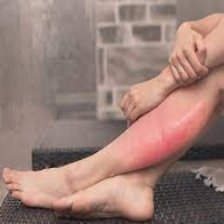

In [17]:
PIL.Image.open(str(cellulitis[16]))

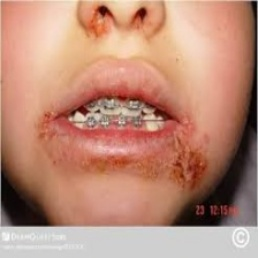

In [18]:
PIL.Image.open(str(BA_impetigo[16]))

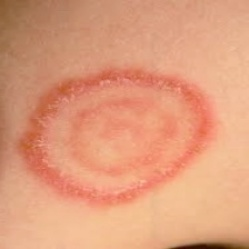

In [19]:
PIL.Image.open(str(FU_ringworm[4]))

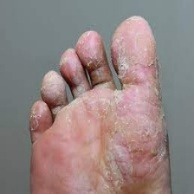

In [20]:
PIL.Image.open(str(FU_athlete_foot[16]))

In [21]:
cv2.imread(str( cellulitis[0])).shape[2]

3

In [22]:
disease_images_train_dic={
    'cellulitis':list(data_dir.glob('BA- cellulitis/*')),
    'impetigo':list(data_dir.glob('BA-impetigo/*')),
    'athlete-foot':list(data_dir.glob('FU-athlete-foot/*')),
    'nail-fungus':list(data_dir.glob('FU-nail-fungus/*')),
    'ringworm':list(data_dir.glob('FU-ringworm/*')),
    'cutaneous-larva-migrans':list(data_dir.glob('PA-cutaneous-larva-migrans/*')),
    'chickenpox':list(data_dir.glob('VI-chickenpox/*')),
    'shingles':list(data_dir.glob('VI-shingles/*')),
#     'normal':list(data_dir.glob('normal/*')),   
}

In [23]:
disease_train_label_dic={
    'cellulitis': 0,
    'impetigo': 1,
    'athlete-foot': 2,
    'nail-fungus': 3,
    'ringworm': 4,
    'cutaneous-larva-migrans':5,
    'chickenpox':6,
    'shingles':7,
}

In [24]:
x_train = []
y_train = []

for image_name, image_paths in disease_images_train_dic.items():
    label = disease_train_label_dic[image_name]
    for image_path in image_paths:
        img = cv2.imread(str(image_path))
        if img is None:
            continue
        image_resize = cv2.resize(img, (224, 224))
        x_train.append(image_resize)
        y_train.append(label)


In [25]:
x_train[0].shape

(224, 224, 3)

In [26]:
len(disease_images_train_dic['ringworm']),len(disease_images_train_dic['shingles'])

(90, 130)

In [27]:
len(x_train)

925

In [28]:
len(y_train)

925

In [29]:
y_train=np.array(y_train)
x_train=np.array(x_train)
y_train.shape

(925,)

In [30]:
dataset_url = '/kaggle/input/datasets/subirbiswas19/skin-disease-dataset/skin-disease-datasaet/test_set'

In [31]:
import pathlib
data_dir=pathlib.Path(dataset_url)
data_dir

PosixPath('/kaggle/input/datasets/subirbiswas19/skin-disease-dataset/skin-disease-datasaet/test_set')

In [32]:
disease_images_test_dic={
    'cellulitis':list(data_dir.glob('BA- cellulitis/*')),
    'impetigo':list(data_dir.glob('BA-impetigo/*')),
    'athlete-foot':list(data_dir.glob('FU-athlete-foot/*')),
    'nail-fungus':list(data_dir.glob('FU-nail-fungus/*')),
    'ringworm':list(data_dir.glob('FU-ringworm/*')),
    'cutaneous-larva-migrans':list(data_dir.glob('PA-cutaneous-larva-migrans/*')),
    'chickenpox':list(data_dir.glob('VI-chickenpox/*')),
    'shingles':list(data_dir.glob('VI-shingles/*')),
  
}
disease_test_label_dic={
    'cellulitis': 0,
    'impetigo': 1,
    'athlete-foot': 2,
    'nail-fungus': 3,
    'ringworm': 4,
    'cutaneous-larva-migrans':5,
    'chickenpox':6,
    'shingles':7,

}

In [33]:
x_test = []
y_test = []

for image_name, image_paths in disease_images_test_dic.items():
    label = disease_train_label_dic[image_name]
    for image_path in image_paths:
        img = cv2.imread(str(image_path))
        if img is None:
            continue
        image_resize = cv2.resize(img, (224, 224))
        x_test.append(image_resize)
        y_test.append(label)


In [34]:
x_train=np.array(x_train)
y_train=np.array(y_train)
x_test=np.array(x_test)
y_test=np.array(y_test)

In [35]:
x_test.shape

(234, 224, 224, 3)

In [36]:
x_train_scaled=x_train/255
x_test_scaled=x_test/255

In [37]:
x_train_scaled[0]

array([[[0.92941176, 0.92941176, 0.92941176],
        [0.93333333, 0.93333333, 0.93333333],
        [0.9372549 , 0.9372549 , 0.9372549 ],
        ...,
        [0.81568627, 0.81960784, 0.83529412],
        [0.83137255, 0.83529412, 0.85098039],
        [0.81568627, 0.81960784, 0.83529412]],

       [[0.92941176, 0.92941176, 0.92941176],
        [0.92941176, 0.92941176, 0.92941176],
        [0.93333333, 0.93333333, 0.93333333],
        ...,
        [0.81960784, 0.82352941, 0.83921569],
        [0.85098039, 0.85490196, 0.87058824],
        [0.84313725, 0.84705882, 0.8627451 ]],

       [[0.92941176, 0.92941176, 0.92941176],
        [0.92941176, 0.92941176, 0.92941176],
        [0.92941176, 0.92941176, 0.92941176],
        ...,
        [0.82745098, 0.83137255, 0.84705882],
        [0.84705882, 0.85098039, 0.86666667],
        [0.82352941, 0.82745098, 0.84313725]],

       ...,

       [[0.48627451, 0.68235294, 0.88627451],
        [0.49411765, 0.69411765, 0.89019608],
        [0.48627451, 0

In [38]:
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False

I0000 00:00:1787951156.650990      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787951156.653867      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [39]:
x_train_scaled.shape

(925, 224, 224, 3)

In [40]:
model = keras.Sequential(
    [
        base_model,
        keras.layers.Dense(len(disease_train_label_dic), activation='softmax')
    ]
)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.fit(x_train_scaled, y_train, epochs=15)

Epoch 1/15


2026-08-28 21:06:16.194987: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-28 21:06:16.331777: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1787951178.128272     137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3156 - loss: 1.8340

2026-08-28 21:06:28.229732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-28 21:06:28.366918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 429ms/step - accuracy: 0.5265 - loss: 1.3875
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8551 - loss: 0.5460
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9059 - loss: 0.3572
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9524 - loss: 0.2593
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9654 - loss: 0.2044
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9686 - loss: 0.1670
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9892 - loss: 0.1324
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9914 - loss: 0.1144
Epoch 9/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9935 - loss: 0.0964
Epoch 10/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9957 - loss: 0.0844
Epoch 11/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9978 - loss: 0.0729
Epoch 12/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9978 -

In [41]:
x_test_scaled.shape

(234, 224, 224, 3)

In [42]:
model.evaluate(x_test_scaled,y_test)

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9762 - loss: 0.1193

2026-08-28 21:06:56.314724: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-28 21:06:56.464401: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-28 21:06:56.601453: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9701 - loss: 0.1266


[0.12659768760204315, 0.9700854420661926]

In [43]:
y_predict=model.predict(x_test_scaled)
# y_predict[0]
y_predicted_labels=[]
for i in y_predict:
    y_predicted_labels.append(np.argmax(i))
    
y_predicted_labels=np.array(y_predicted_labels)

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 674ms/step


In [44]:
from sklearn.metrics import confusion_matrix, classification_report
print("Classification Report: \n", classification_report(y_test, y_predicted_labels))

Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        34
           1       1.00      1.00      1.00        20
           2       0.89      1.00      0.94        32
           3       1.00      1.00      1.00        33
           4       0.92      0.96      0.94        23
           5       1.00      0.84      0.91        25
           6       1.00      1.00      1.00        34
           7       1.00      0.97      0.98        33

    accuracy                           0.97       234
   macro avg       0.97      0.97      0.97       234
weighted avg       0.97      0.97      0.97       234



In [45]:
conf_matrix = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)
conf_matrix


<tf.Tensor: shape=(8, 8), dtype=int32, numpy=
array([[33,  0,  0,  0,  1,  0,  0,  0],
       [ 0, 20,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 32,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 33,  0,  0,  0,  0],
       [ 1,  0,  0,  0, 22,  0,  0,  0],
       [ 0,  0,  4,  0,  0, 21,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 34,  0],
       [ 0,  0,  0,  0,  1,  0,  0, 32]], dtype=int32)>

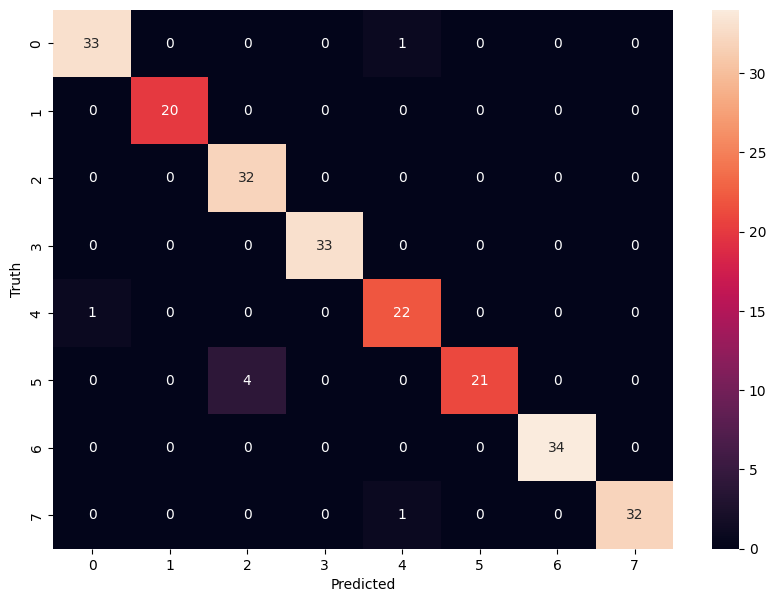

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()


In [47]:
#!pip install gradio
import gradio as gr
import numpy as np
import cv2

# Disease Class Names (must match the order of disease_train_label_dic values 0-7)
class_names = [
    'cellulitis', 'impetigo', 'athlete-foot', 'nail-fungus',
    'ringworm', 'cutaneous-larva-migrans', 'chickenpox', 'shingles'
]

def predict_skin_disease(img):
    if img is None:
        return None
    # gradio gives RGB, model was trained on BGR (cv2.imread) - convert to match
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img_resized = cv2.resize(img_bgr, (224,224))
    img_scaled = img_resized/255.0
    img_reshaped = np.reshape(img_scaled, (1,224,224,3))
    prediction = model.predict(img_reshaped)[0]
    return {class_names[i]: float(prediction[i]) for i in range(len(class_names))}

# Create the Interface
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# \U0001fa7a Skin Disease AI Diagnostic Tool")
    gr.Markdown("Upload a clear photo of the skin condition to see the prediction.")

    with gr.Row():
        input_img = gr.Image()
        output_label = gr.Label(num_top_classes=3)

    btn = gr.Button("Analyze Image")
    btn.click(fn=predict_skin_disease, inputs=input_img, outputs=output_label)

# Launch
demo.launch(share=True)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://b8f89595ffd4a4c04c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
